In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('stu_perf.csv')
df = df.drop(columns=['Unnamed: 0'])
df.head()

,traveltime,studytime,failures,schoolsup,famsup,paid,activities,internet,freetime,goout
0,2,2,0,yes,no,no,no,no,3,4
1,1,2,0,no,yes,no,no,yes,3,3
2,1,2,3,yes,no,yes,no,yes,3,2
3,1,3,0,no,yes,yes,yes,yes,2,2
4,1,2,0,no,yes,yes,no,no,3,2


In [3]:
df.shape

(1044, 10)

In [4]:
df.isnull().sum()

traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
internet      0
freetime      0
goout         0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   traveltime  1044 non-null   int64 
 1   studytime   1044 non-null   int64 
 2   failures    1044 non-null   int64 
 3   schoolsup   1044 non-null   object
 4   famsup      1044 non-null   object
 5   paid        1044 non-null   object
 6   activities  1044 non-null   object
 7   internet    1044 non-null   object
 8   freetime    1044 non-null   int64 
 9   goout       1044 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 81.7+ KB


In [6]:
df.columns

Index(['traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid',
       'activities', 'internet', 'freetime', 'goout'],
      dtype='object')

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['schoolsup'] = le.fit_transform(df['schoolsup'])
df['famsup'] = le.fit_transform(df['famsup'])
df['paid'] = le.fit_transform(df['paid'])
df['activities'] = le.fit_transform(df['activities'])
df['internet'] = le.fit_transform(df['internet'])

In [8]:
df.head()

,traveltime,studytime,failures,schoolsup,famsup,paid,activities,internet,freetime,goout
0,2,2,0,1,0,0,0,0,3,4
1,1,2,0,0,1,0,0,1,3,3
2,1,2,3,1,0,1,0,1,3,2
3,1,3,0,0,1,1,1,1,2,2
4,1,2,0,0,1,1,0,0,3,2


In [9]:
X = df[[
    "traveltime",
    "studytime",
    "failures",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "internet",
    "freetime",
    "goout"
]]

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.decomposition import TruncatedSVD

svd2 = TruncatedSVD(n_components=4, random_state=42)
X_2D = svd2.fit_transform(X)


print(X_2D.shape)   # should be (rows, 2)

(1044, 4)


In [12]:
X_2D

array([[ 5.57162956, -0.34292911, -0.69159019,  0.42259487],
       [ 4.92050874,  0.20010688, -0.09344127, -0.45168238],
       [ 4.40974898,  0.23160608,  0.81104365,  0.40044215],
       ...,
       [ 2.59931196,  1.35592984, -0.37402394,  1.12448459],
       [ 6.55266958, -1.72388544, -0.30733478,  0.21585381],
       [ 4.40126926,  0.37943276,  2.04890849,  1.70587415]],
      shape=(1044, 4))

In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px

In [14]:
bin_cols = ["schoolsup","famsup","paid","activities","internet"]

le = LabelEncoder()

for c in bin_cols:
    df[c] = le.fit_transform(df[c])


In [15]:
num_cols = ["traveltime","studytime","failures","freetime","goout"]

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)

df_clean = df[mask].copy()

print("Rows removed:", len(df) - len(df_clean))


Rows removed: 305


In [16]:
feature_cols = [
    "traveltime","studytime","failures",
    "schoolsup","famsup","paid","activities","internet",
    "freetime","goout"
]

X = df_clean[feature_cols]


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2D = svd2.fit_transform(X_scaled)



In [19]:
best_k = 2
best_score = -1

for k in range(2, 12):
    km = KMeans(n_clusters=k, init="k-means++", n_init=40, random_state=42)
    labels = km.fit_predict(X_2D)
    score = silhouette_score(X_2D, labels)
    print(f"K={k} → Silhouette={score:.3f}")

    if score > best_score:
        best_score = score
        best_k = k

print("\nBEST K:", best_k)
print("BEST SCORE:", best_score)



K=2 → Silhouette=0.322
K=3 → Silhouette=0.365
K=4 → Silhouette=0.328
K=5 → Silhouette=0.343
K=6 → Silhouette=0.344
K=7 → Silhouette=0.346
K=8 → Silhouette=0.343
K=9 → Silhouette=0.349
K=10 → Silhouette=0.341
K=11 → Silhouette=0.344

BEST K: 3
BEST SCORE: 0.36541421996640894


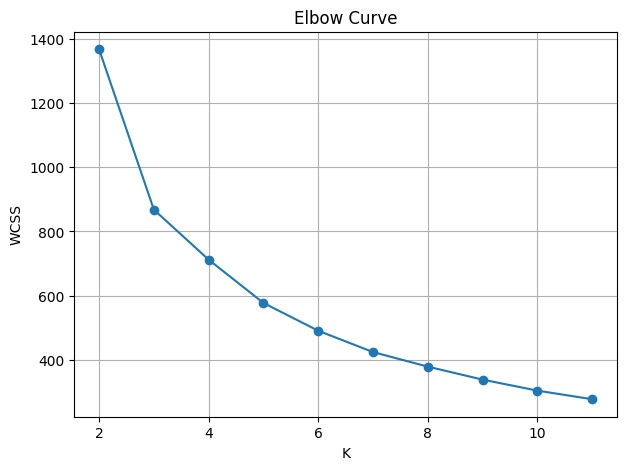

In [20]:
wcss = []

for k in range(2, 12):
    km = KMeans(n_clusters=k, n_init=40, random_state=42)
    km.fit(X_2D)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,12), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.grid(True)
plt.show()



In [21]:
kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=50,
    random_state=42
)

labels = kmeans.fit_predict(X_2D)



print("Final Silhouette:",
    silhouette_score(X_2D, labels))


Final Silhouette: 0.36541421996640894


In [22]:
df_clean["Final_Cluster"] = labels

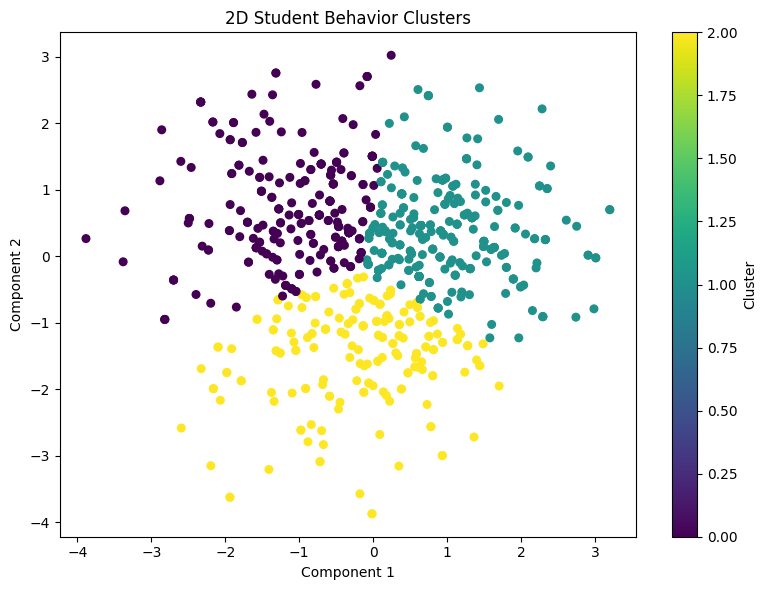

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(X_2D[:,0], X_2D[:,1], c=labels, s=30)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("2D Student Behavior Clusters")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


In [24]:
svd3 = TruncatedSVD(n_components=3, random_state=42)
X_3D = svd3.fit_transform(X_scaled)

df_clean["C1"] = X_3D[:,0]
df_clean["C2"] = X_3D[:,1]
df_clean["C3"] = X_3D[:,2]


In [25]:
fig = px.scatter_3d(
    df_clean,
    x="C1",
    y="C2",
    z="C3",
    color="Final_Cluster",
    title="3D Student Behavior Clusters"
)

fig.show()


In [26]:
# Save results for the Meta-Model
df_clean.to_csv('stu_pref1.csv', index=False)
print("Career results exported to stu_pref1.csv")

Career results exported to stu_pref1.csv


In [27]:
import pickle
with open('student_performance_kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)